# Regularization (정칙화)
- 차수가 높아질수록 과대적합이 발생하여 예측 성능이 저하되는 문제 발생
- 과대적합 방지를 위해 가중치 크기 제어
- 기존의 비용함수에 벌점(Penality)를 추가하여 가중치의 크기 제어 가능
- 가중치에 대한 벌점을 부가하기 때문에 데이터의 스케일에 민감
    - 데이터를 정규화 또는 표준화하여 보다 정확하게 예측할 수 있도록 함

## 규제 방법
- L1 규제
    - 모델의 가중치 값에 절대값을 적용하여 벌점 부여 <br>
$L1 = λ\sum|w_i|$
    - 가중치의 일부를 0으로 만들 수 있음
- L2 규제
    - 모델의 가중치에 제곱을 적용하여 벌점 부여 <br>
$L2 = λ\sum{w_i}^2$
    - 모든 가중치 값을 작게 만들어주어, 그 영향을 줄이는 방식

## 규제 모델
- Ridge Regression
    - L2 규제 적용
- Lasso Regression
    - L1 규제 적용
- Elastic Net
    - L1 + L2 규제 적용

- 위에서 데이터 정규화 표준화 : min-max scaler / standard scaler

In [ ]:
# L1 규제는 0으로 만들어 반영하지 않는 것을 만드는 것과 마찬가지
# = MSE + L1 공식
# L2 규제
# = MSE + L2 공식

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

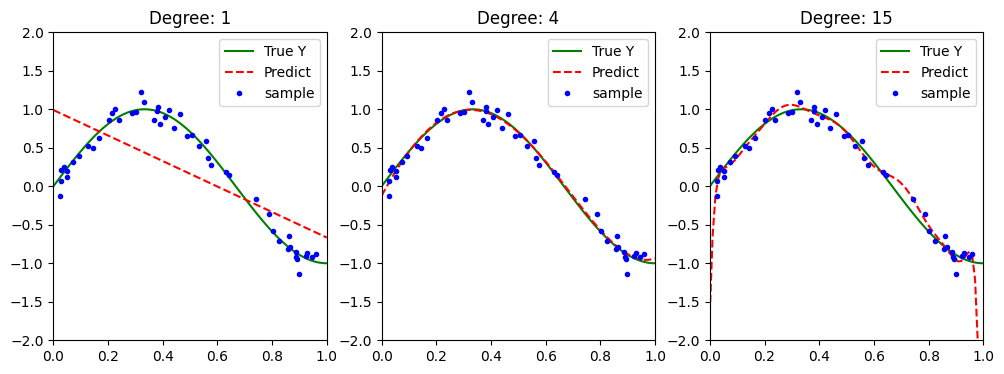

In [2]:
# 데이터 생성
def sin(x):
    return np.sin(1.5 * np.pi * x)

x = np.sort(np.random.rand(50))
y = sin(x) + 0.1 * np.random.randn(50)

# 차수에 따른 파이프라인 구축 및 결과 시각화
degrees = [1, 4, 15]
plt.figure(figsize=(12, 4))

for i,d in enumerate(degrees):
    poly = PolynomialFeatures(degree=d)
    reg = LinearRegression()
    pipeline = Pipeline([("polynormial", poly), ("regression", reg)])
    pipeline.fit(x.reshape(-1, 1), y)

    x_test = np.linspace(0, 1, 100)
    y_pred = pipeline.predict(x_test.reshape(-1, 1))

    plt.subplot(1, len(degrees), i+1)
    plt.plot(x_test, sin(x_test), 'g-', label="True Y")
    plt.plot(x_test, y_pred, 'r--', label = "Predict")
    plt.plot(x, y, 'b.', label = "sample")
    plt.axis([0, 1, -2, 2])
    plt.legend()
    plt.title(f"Degree: {d}")

    # 1차 4차 15차 다항으로 바꿨을 때 어떻게 바뀌는지
    # 1차 함수는 예측선이 하나로 데이터 오차가 크다
    # 4차는 거의 일치한다
    # 15차 아예 파란 샘플(파란)점들을 따라 빨간 predict 선이 움직인다.
    #  -> 이렇게 너무 학습데이터에 매몰되면 새로운 데이터(test) 오차가 커진다 : 과대적합

- 4차항 변환의 경우, 예측선과 실제데이터가 거의 일치
- 1차항의 경우, 예측선이 단순하여 실제데이터와 오차가 큼
- 15차항 변환의 경우, 예측선이 학습 데이터에 과도하게 학습하여 실제 데이터(Ture Y)와의 오차가 큰 것을 확인 가능

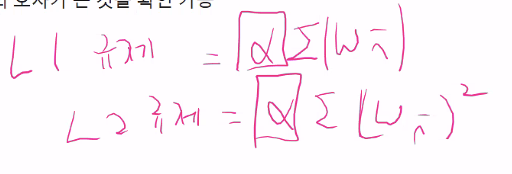

위의 알파값 -> 규제강도 (패널티 많이 줌)

## 규제 강도(α, alpha)
- 모델을 단순하게 해주고 학습데이터 성능과 평가데이터 성능 사이를 절충할 방법
    - 과대적합 또는 과소적합 현상을 해결하기 위한 방법
- 과대적합이 발생한 상황에서 모델의 α를 증가시키면 학습 성능은 감소하지만 평가성능은 증가함
- α를 너무 크게 지정하는 경우, 가중치에 대한 규제가 강해지며 너무 모델이 단순화되어 과소적합이 발생할 수 있음
- α를 아주 작게 하거나 0으로 지정하는 경우, 가중치에 대한 규제가 약해지며 과대적합이 발생할 수 있음
    - α가 0인 경우, Linear Regression과 동일

# Ridge Regression
- 기존의 선형회귀식에서 규제항(L2 Regularization)이 적용된 모델
- linear_model의 Ridge에 구현되어 있음
- MSE가 최소가 되게 하는 가중치와 편향을 찾는 동시에 가중치들의 제곱합이 최소가 되도록 적절한 가중치와 편향을 찾음
- L2 규제의 효과로 가중치가 0이 되진 않지만 모델의 복잡도를 제어할 수 있음
    - 특성들이 출력에 미치는 영향력이 줄어들어 현재 특성들에 덜 의존하게 됨
- L2 정규화의 비용함수(손실함수) <br>
$Cost(Loss) = MSE + α\sum(x_i)^2$


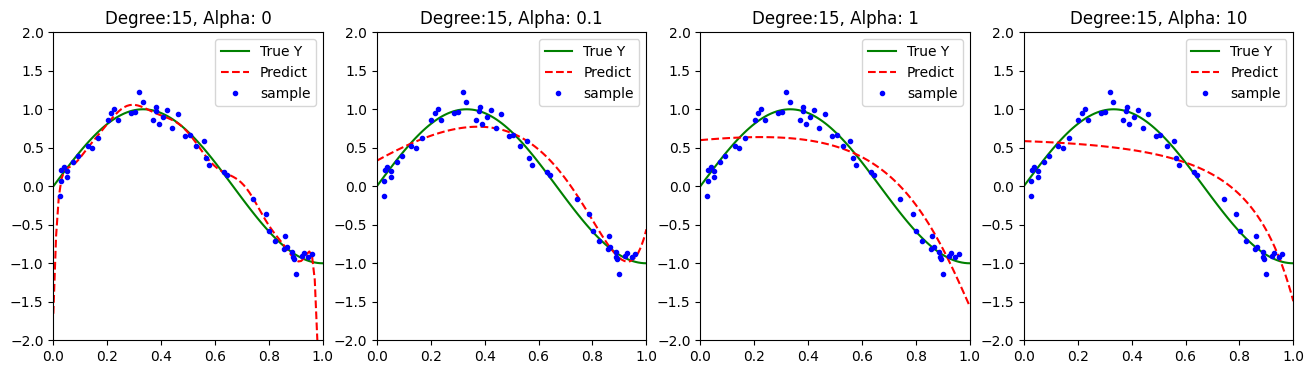

In [3]:
# 15차항 변환된 데이터를 기반으로 L2 규제 적용(Ridge Regression)
from sklearn.linear_model import Ridge

alphas = [0, 0.1, 1, 10]
plt.figure(figsize=(16, 4))

for i, a in enumerate(alphas):
    poly = PolynomialFeatures(degree=15)
    ridge = Ridge(alpha=a)
    pipeline = Pipeline([("polynormial", poly), ("ridge", ridge)])
    pipeline.fit(x.reshape(-1, 1), y)

    x_test = np.linspace(0, 1, 100)
    y_pred = pipeline.predict(x_test.reshape(-1, 1))

    plt.subplot(1, len(alphas), i+1)
    plt.plot(x_test, sin(x_test), 'g-', label="True Y")
    plt.plot(x_test, y_pred, 'r--', label = "Predict")
    plt.plot(x, y, 'b.', label = "sample")
    plt.axis([0, 1, -2, 2])
    plt.legend()
    plt.title(f"Degree:15, Alpha: {a}")

    # 알파에 따라 우리 모델이 얼마나 단순해지는지 확인해볼 수 있다.

- 규제강도(α)가 0인 경우, 규제가 적용되지 않아 Linear Regression과 동일한 결과 (과대적합 발생)
- 규제강도가 커질수록, 회귀선이 단순화되는 것을 확인 가능
    - 규제 효과로 인해 모델이 일반화됨

### [예제] 당뇨병 수치에 대한 예측

In [4]:
# 데이터 추출
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [7]:
# 데이터 전처리
# 데이터 표준화
# 단위에 대해 민감함 (scale에 대해 표준화 먼저 처리 해주어야 한다.)
from sklearn.preprocessing import * # 모든 것들을 import
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(diabetes.data)
poly = PolynomialFeatures(degree=3, include_bias=False) # 3차항
X_poly = poly.fit_transform(X_scaled)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_poly,
                                                    diabetes.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [8]:
# 모델 학습 및 평가 (alpha=1)
ridge1 = Ridge(alpha=1) # 알파값설정
ridge1.fit(X_train, y_train) # 학습

# 평가
print("Train score : ", ridge1.score(X_train, y_train))
print("Test score : ", ridge1.score(X_test, y_test))

Train score :  0.6217440034694295
Test score :  0.3638108417964866


In [9]:
# 모델 학습 및 평가 (alpha=0.1)
ridge01 = Ridge(alpha=0.1) # 알파값설정
ridge01.fit(X_train, y_train) # 학습

# 평가
print("Train score : ", ridge01.score(X_train, y_train))
print("Test score : ", ridge01.score(X_test, y_test))

Train score :  0.6673520552956198
Test score :  0.28245553120698463


In [10]:
# 모델 학습 및 평가 (alpha=10)
ridge10 = Ridge(alpha=10) # 알파값설정
ridge10.fit(X_train, y_train) # 학습

# 평가
print("Train score : ", ridge10.score(X_train, y_train))
print("Test score : ", ridge10.score(X_test, y_test))

# 알파값이 커질수록 train값은 줄지만 test 값은 올랐다
# 알파값이 10일 때(규제 강도를 높였을 때) 성능이 개선되었다.

Train score :  0.5720779319156118
Test score :  0.416258280352067


### L2 규제효과
- L2 규제를 적용하면 특정 가중치가 너무 커지거나 작은 값을 가지지 않도록 설정
- 규제강도가 커질수록 특정 가중치에 값이 쏠리는 현상이 제거
    - 일부만 가지고 모델링하는 것이 아니라 특성을 골고루 사용한다는 의미로 해석 가능

In [15]:
# 규제강도별 가중치값 조회
ridge01 = Ridge(alpha=0.1).fit(diabetes.data, diabetes.target)
ridge01_coef = pd.Series(ridge01.coef_, index=diabetes.feature_names)
ridge1 = Ridge(alpha=1).fit(diabetes.data, diabetes.target)
ridge1_coef = pd.Series(ridge1.coef_, index=diabetes.feature_names)
ridge10 = Ridge(alpha=10).fit(diabetes.data, diabetes.target)
ridge10_coef = pd.Series(ridge10.coef_, index=diabetes.feature_names)

Text(0.5, 1.0, 'Alpha : 10')

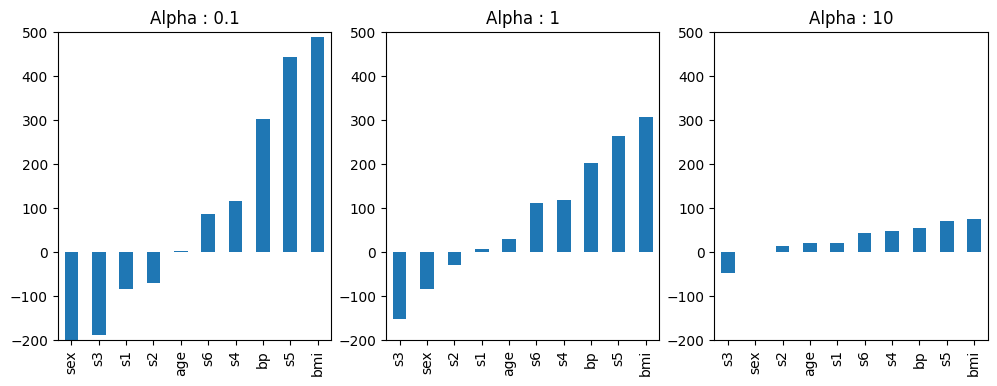

In [16]:
# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
ridge01_coef.sort_values().plot(kind='bar')
plt.ylim(-200,500)
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
ridge1_coef.sort_values().plot(kind='bar')
plt.ylim(-200,500)
plt.title("Alpha : 1")
plt.subplot(1,3,3)
ridge10_coef.sort_values().plot(kind='bar')
plt.ylim(-200,500)
plt.title("Alpha : 10")

# L2 가중치가 너무 한쪽에 몰리는 것을 방지
# 특성별 의존도가 점점 비슷해지는 것을 볼 수 있다.
# 과대적합을 해소

# 저번에는 차수를 올리면 올릴 수록 학습은 잘 되는데 테스트가 떨어져 과대적합이 발생할 수 있다.
# 차수가 높아진 것에 대해 과대적합의 오류를 줄여주고자 가중치 규제를 한다.
# 그렇게 차수를 줄인 것과 높여 가중치 규제를 하며 비교해 모델을 선택하게 된다.

# 가중치가 크면 클 수록 모델 단순화
# 모든 변수들 별로 골고루 특성을 반영할 수 있게 된다.

# Lasso Regression
- 기존의 선형회귀식에서 규제항(L1 Regularization)이 적용된 모델
- linear_model의 Lasso에 구현되어 있음
- MSE가 최소가 되게 하는 가중치와 편향을 찾는 동시에 가중치들의 절대값의 합이 최소가 되도록 적절한 가중치와 편향을 찾음
- L1 규제의 효과로 어떤 특성들은 0이 되어서 모델을 만들 때 사용되지 않음
    - 특성 선택(Feature selection) 효과가 있음
- 모델에서 가장 중요한 특성이 무엇인지 알게 되어 모델의 설명력이 좋아짐
- L1 정규화의 비용함수(손실함수) <br>
$Cost(Loss) = MSE + α\sum|x_i|$


절대값의 합이 최소가 되어야하기 때문에 어떤 가중치에 대해 0으로 만들어버려 어떤 특성은 0이 된다. <br>
중요한 특성에 대해 보게 된다 -> 모델의 설명력이 좋을 수 있다.

### [예제] 당뇨병 수치에 대한 예측

In [17]:
# 데이터 추출
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [18]:
# 데이터 전처리
# 데이터 표준화
# 이 파트는 ridge와 동일
from sklearn .preprocessing import *
scaler = MinMaxScaler() # 데이터 표준화
X_scaled = scaler. fit_transform(diabetes.data)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_poly,
                                                    diabetes.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [21]:
# 모델 학습 및 평가 (alpha=0.1)
from sklearn.linear_model import Lasso
lasso01 = Lasso(alpha=0.1)
lasso01.fit(X_train,y_train)
print('Train Score : ', lasso01.score(X_train, y_train))
print('Test Score : ', lasso01.score(X_test, y_test))

Train Score :  0.60502599202152
Test Score :  0.3740965180274064


In [19]:
# 모델 학습 및 평가 (alpha=1)
lasso1 = Lasso(alpha=1)
# 학습
lasso1.fit(X_train,y_train)
# 성능평가
print('Train Score : ', lasso1.score(X_train, y_train))
print('Test Score : ', lasso1.score(X_test, y_test))

Train Score :  0.5407066018420341
Test Score :  0.3933244251432546


In [23]:
# 모델 학습 및 평가 (alpha=10)
lasso10 = Lasso(alpha=10)
lasso10.fit(X_train, y_train)
print("Train score", lasso10.score(X_train, y_train))
print("Test score", round(lasso10.score(X_test, y_test),6))
lasso10.coef_ # 가중치들이 다 0이 되어버린 것을 알 수 있다.
# 0.1 -> 1 일 때는 개선 된 것을 알 수 있지만
# 10에서는 모델이 죽어버림
# 1에서 조금 더 크게 규제강도를 옮기며 테스트 할 수 있다.

Train score 0.0
Test score -0.0


array([ 0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0., -0.,
        0.,  0.,  0., -0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,
        0.,  0., -0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.,  0.,  0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0

### L1 규제효과
- L1 규제를 적용하면 특정 가중치를 선택
    - 중요한 특성만 사용하는 의미로 해석 가능

In [24]:
# 규제강도별 가중치값 조회
lasso01 = Lasso(alpha=0.1).fit(diabetes.data, diabetes.target)
lasso01_coef = pd.Series(lasso01.coef_, index=diabetes.feature_names)
lasso1 = Lasso(alpha=1).fit(diabetes.data, diabetes.target)
lasso1_coef = pd.Series(lasso1.coef_, index=diabetes.feature_names)
lasso10 = Lasso(alpha=10).fit(diabetes.data, diabetes.target)
lasso10_coef = pd.Series(lasso10.coef_, index=diabetes.feature_names)

Text(0.5, 1.0, 'Alpha : 10')

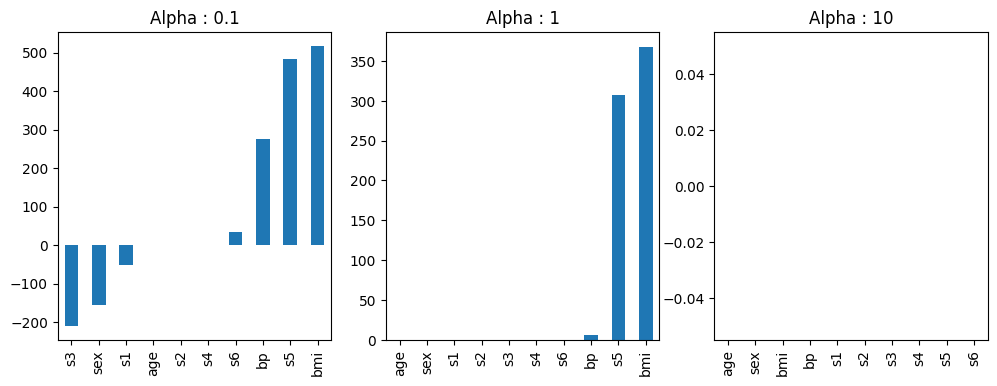

In [25]:
# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
lasso01_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
lasso1_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 1") # 나머지는 0이 되고 3개의 차원만 남음
plt.subplot(1,3,3)
lasso10_coef.sort_values().plot(kind='bar') # 아예 남지 않음
plt.title("Alpha : 10")

# lasso 는 아예 가중치를 0으로 만들어버리는 효과가 있다.
# 실제로 내가 변수를 선택하는 효과를 가질 수 있다.

# [실습] 보스턴 주택 가격 예측에 대하여 정칙화 적용해보기
1. [boston 데이터](https://drive.google.com/file/d/17ygxKFk3IyOhe6lIWm1OBqUY6eeDq3I8/view?usp=sharing) 추출
2. 데이터 표준화 또는 정규화
    - MinMaxScaler
    - StandardScaler
3. Regularization이 적용된 회귀분석
    - Ridge
    - Lasso
    - 규제강도
4. 다양한 조합을 기준으로 회귀분석을 수행하고 최적의 모델을 찾아보자.
    - 어떤 모델이 성능이 가장 좋았는가?

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
boston = pd.read_csv('/content/drive/MyDrive/boston.csv')
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [33]:
X_data = boston.drop(columns='MEDV')
y_data = boston['MEDV']

##MinMaxScaler

In [55]:
# 1. MinMaxScaler
from sklearn.preprocessing import *
scaler1= MinMaxScaler()
X_scaled1 = scaler1.fit_transform(X_data)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly1 = poly.fit_transform(X_scaled1)

import sklearn.model_selection import train_test_split

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_poly1,
                                                    y_data,
                                                    test_size=0.3,
                                                    random_state=0)

### Ridge

In [35]:
from sklearn.linear_model import Ridge
# 모델 학습 및 평가 (alpha=1)
ridge1 = Ridge(alpha=1) # 알파값설정
# 학습
ridge1.fit(X_train, y_train)

# 평가
print("Train score : ", ridge1.score(X_train, y_train))
print("Test score : ", ridge1.score(X_test, y_test))

Train score :  0.9227252648481711
Test score :  0.8110781652933781


In [36]:
# 모델 학습 및 평가 (alpha=1)
ridge01 = Ridge(alpha=0.1) # 알파값설정
# 학습
ridge01.fit(X_train, y_train)

# 평가
print("Train score : ", ridge01.score(X_train, y_train))
print("Test score : ", ridge01.score(X_test, y_test))

Train score :  0.9530277196640089
Test score :  0.8193922344623137


In [37]:
# 모델 학습 및 평가 (alpha=10)
ridge10 = Ridge(alpha=10) # 알파값설정
ridge10.fit(X_train, y_train) # 학습

# 평가
print("Train score : ", ridge10.score(X_train, y_train))
print("Test score : ", ridge10.score(X_test, y_test))

Train score :  0.8500068505959564
Test score :  0.7570985424765933


In [43]:
# 규제강도별 가중치값 조회
ridge01 = Ridge(alpha=0.1).fit(X_data, y_data)
ridge01_coef = pd.Series(ridge01.coef_, index=X_data.columns)
ridge1 = Ridge(alpha=1).fit(X_data, y_data)
ridge1_coef = pd.Series(ridge1.coef_, index=X_data.columns)
ridge10 = Ridge(alpha=10).fit(X_data, y_data)
ridge10_coef = pd.Series(ridge10.coef_, index=X_data.columns)

Text(0.5, 1.0, 'Alpha : 10')

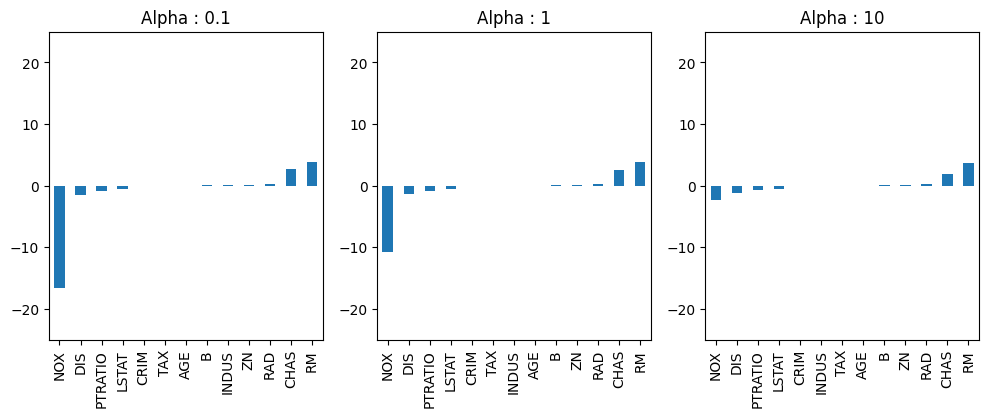

In [54]:
# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
ridge01_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
ridge1_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 1")
plt.subplot(1,3,3)
ridge10_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 10")

### Lasso

In [45]:
# 모델 학습 및 평가 (alpha=0.1)
from sklearn.linear_model import Lasso
lasso01 = Lasso(alpha=0.1)
lasso01.fit(X_train,y_train)
print('Train Score : ', lasso01.score(X_train, y_train))
print('Test Score : ', lasso01.score(X_test, y_test))

Train Score :  0.7764761042085542
Test Score :  0.6915398720419157


In [46]:
# 모델 학습 및 평가 (alpha=1)
lasso1 = Lasso(alpha=1)
lasso1.fit(X_train,y_train)
print('Train Score : ', lasso1.score(X_train, y_train))
print('Test Score : ', lasso1.score(X_test, y_test))

Train Score :  0.2646238502905458
Test Score :  0.21482387824136517


In [50]:
# 모델 학습 및 평가 (alpha=10)
lasso10 = Lasso(alpha=10)
lasso10.fit(X_train,y_train)
print('Train Score : ', lasso10.score(X_train, y_train))
print('Test Score : ', round(lasso10.score(X_test, y_test),2))

Train Score :  0.0
Test Score :  -0.01


In [51]:
# 규제강도별 가중치값 조회
lasso01 = Lasso(alpha=0.1).fit(X_data,y_data)
lasso01_coef = pd.Series(lasso01.coef_, index=X_data.columns)
lasso1 = Lasso(alpha=1).fit(X_data,y_data)
lasso1_coef = pd.Series(lasso1.coef_, index=X_data.columns)
lasso10 = Lasso(alpha=10).fit(X_data,y_data)
lasso10_coef = pd.Series(lasso10.coef_, index=X_data.columns)

Text(0.5, 1.0, 'Alpha : 10')

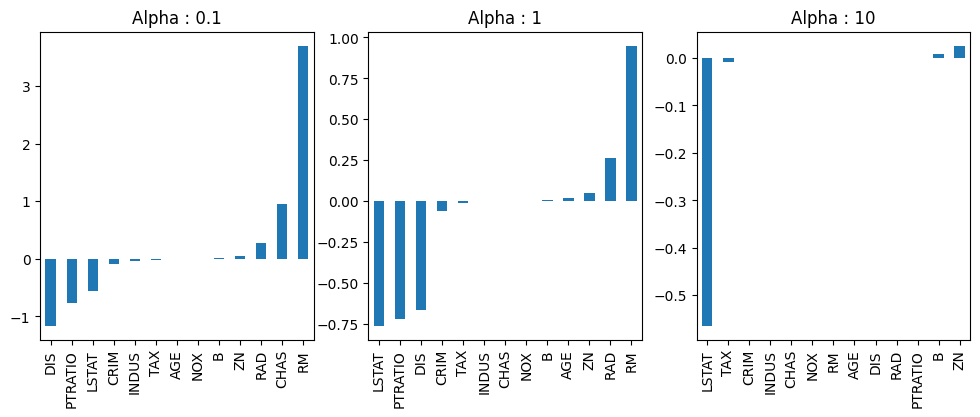

In [52]:
# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
lasso01_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
lasso1_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 1") # 나머지는 0이 되고 3개의 차원만 남음
plt.subplot(1,3,3)
lasso10_coef.sort_values().plot(kind='bar') # 아예 남지 않음
plt.title("Alpha : 10")

## StandardScaler

In [56]:
# 2. StandardScaler
from sklearn.preprocessing import *
scaler2= StandardScaler()
X_scaled2 = scaler2.fit_transform(X_data)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly2 = poly.fit_transform(X_scaled2)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_poly2,
                                                    y_data,
                                                    test_size=0.3,
                                                    random_state=0)

### Ridge

In [57]:
from sklearn.linear_model import Ridge
# 모델 학습 및 평가 (alpha=1)
ridge2 = Ridge(alpha=1) # 알파값설정
# 학습
ridge2.fit(X_train, y_train)

# 평가
print("Train score : ", ridge2.score(X_train, y_train))
print("Test score : ", ridge2.score(X_test, y_test))

Train score :  0.9913858075946909
Test score :  0.7231790653310728


In [58]:
# 모델 학습 및 평가 (alpha=0.1)
ridge2 = Ridge(alpha=0.1) # 알파값설정
# 학습
ridge2.fit(X_train, y_train)

# 평가
print("Train score : ", ridge2.score(X_train, y_train))
print("Test score : ", ridge2.score(X_test, y_test))

Train score :  0.9962741920356618
Test score :  0.5575769737977052


In [59]:
# 모델 학습 및 평가 (alpha=10)
ridge2 = Ridge(alpha=10) # 알파값설정
# 학습
ridge2.fit(X_train, y_train)

# 평가
print("Train score : ", ridge2.score(X_train, y_train))
print("Test score : ", ridge2.score(X_test, y_test))

Train score :  0.9804073677908904
Test score :  0.7978860847174323


Text(0.5, 1.0, 'Alpha : 10')

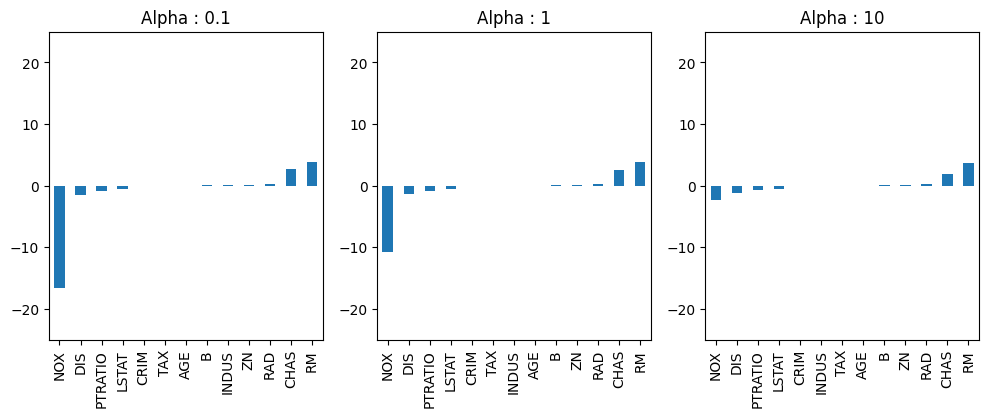

In [60]:
# 규제강도별 가중치값 조회
ridge01 = Ridge(alpha=0.1).fit(X_data, y_data)
ridge01_coef = pd.Series(ridge01.coef_, index=X_data.columns)
ridge1 = Ridge(alpha=1).fit(X_data, y_data)
ridge1_coef = pd.Series(ridge1.coef_, index=X_data.columns)
ridge10 = Ridge(alpha=10).fit(X_data, y_data)
ridge10_coef = pd.Series(ridge10.coef_, index=X_data.columns)

# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
ridge01_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
ridge1_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 1")
plt.subplot(1,3,3)
ridge10_coef.sort_values().plot(kind='bar')
plt.ylim(-25,25)
plt.title("Alpha : 10")

### Lasso

In [65]:
# 모델 학습 및 평가 (alpha=0.1)
from sklearn.linear_model import Lasso
lasso01 = Lasso(alpha=0.1)
lasso01.fit(X_train,y_train)
print('Train Score : ', lasso01.score(X_train, y_train))
print('Test Score : ', lasso01.score(X_test, y_test))

Train Score :  0.9487619876645889
Test Score :  0.8135618704661677


In [66]:
# 모델 학습 및 평가 (alpha=1)
lasso1 = Lasso(alpha=1)
lasso1.fit(X_train,y_train)
print('Train Score : ', lasso1.score(X_train, y_train))
print('Test Score : ', lasso1.score(X_test, y_test))

Train Score :  0.8309568748910249
Test Score :  0.7307345266133414


In [67]:
# 모델 학습 및 평가 (alpha=10)
lasso10 = Lasso(alpha=10)
lasso10.fit(X_train,y_train)
print('Train Score : ', lasso10.score(X_train, y_train))
print('Test Score : ', round(lasso10.score(X_test, y_test),2))

Train Score :  0.3417675916479781
Test Score :  0.36


Text(0.5, 1.0, 'Alpha : 10')

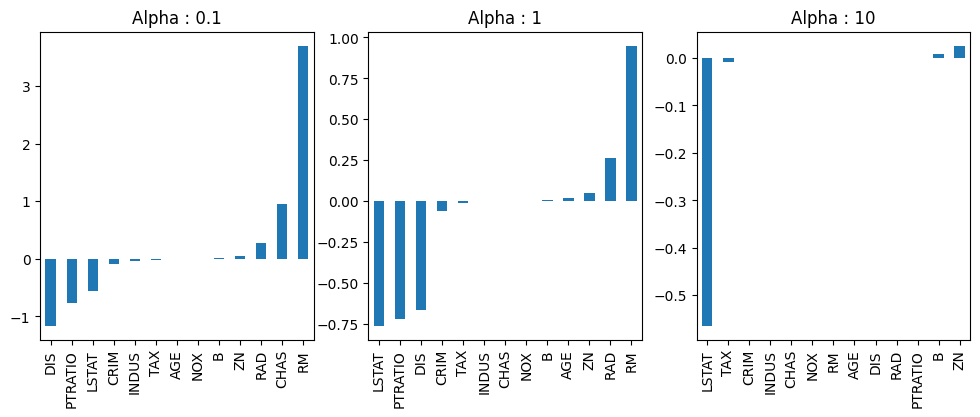

In [64]:
# 규제강도별 가중치값 조회
lasso01 = Lasso(alpha=0.1).fit(X_data,y_data)
lasso01_coef = pd.Series(lasso01.coef_, index=X_data.columns)
lasso1 = Lasso(alpha=1).fit(X_data,y_data)
lasso1_coef = pd.Series(lasso1.coef_, index=X_data.columns)
lasso10 = Lasso(alpha=10).fit(X_data,y_data)
lasso10_coef = pd.Series(lasso10.coef_, index=X_data.columns)

# 가중치 시각화
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
lasso01_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 0.1")
plt.subplot(1,3,2)
lasso1_coef.sort_values().plot(kind='bar')
plt.title("Alpha : 1") # 나머지는 0이 되고 3개의 차원만 남음
plt.subplot(1,3,3)
lasso10_coef.sort_values().plot(kind='bar') # 아예 남지 않음
plt.title("Alpha : 10")

## 강사님

In [ ]:
# 데이터 추출
import pandas as pd
boston = pd.read_csv('/content/boston.csv')
X_data = boston.drop(columns='MEDV')
y_data = boston['MEDV']

In [ ]:
# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data,
                                                    test_size=0.3, random_state=0)

In [ ]:
# score를 저장할 데이터프레임 만들기
scores = pd.DataFrame(columns=['scaler', 'model', 'alpha', 'train_score', 'test_score'])

In [ ]:
from tempfile import SpooledTemporaryFile
import numpy as np
from sklearn.preprocessing import *
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import Pipeline

alphas = np.linspace(0, 3, 31)
scalers = [StandardScaler(), MinMaxScaler()]

for s in scalers:
    for a in alphas:
        # scaler와 다항식 적용
        scaler = s
        poly = PolynomialFeatures(degree=3, include_bias=False)
        ridge = Ridge(alpha=a)
        pipeline = Pipeline([("scaler", scaler), ("poly", poly), ('ridge', ridge)])
        pipeline.fit(X_train, y_train)
        scores.loc[len(scores)] = [s, "Ridge", a,
                                   pipeline.score(X_train, y_train),
                                   pipeline.score(X_test, y_test)]
scores.sort_values("test_score", ascending=False)

,scaler,model,alpha,train_score,test_score
32,MinMaxScaler(),Ridge,0.1,0.953244,0.819528
33,MinMaxScaler(),Ridge,0.2,0.945714,0.816461
34,MinMaxScaler(),Ridge,0.3,0.940899,0.815105
35,MinMaxScaler(),Ridge,0.4,0.937223,0.814327
36,MinMaxScaler(),Ridge,0.5,0.934169,0.813760
...,...,...,...,...,...
3,StandardScaler(),Ridge,0.3,0.994514,0.661761
2,StandardScaler(),Ridge,0.2,0.995268,0.630067
1,StandardScaler(),Ridge,0.1,0.996302,0.546183
31,MinMaxScaler(),Ridge,0.0,1.000000,-102.859288


In [ ]:
for s in scalers:
    for a in alphas:
        # scaler와 다항식 적용
        scaler = s
        poly = PolynomialFeatures(degree=3, include_bias=False)
        lasso = Lasso(alpha=a)
        pipeline = Pipeline([("scaler", scaler), ("poly", poly), ('lasso', lasso)])
        pipeline.fit(X_train, y_train)
        scores.loc[len(scores)] = [s, "Lasso", a,
                                   pipeline.score(X_train, y_train),
                                   pipeline.score(X_test, y_test)]

In [ ]:
pipeline

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('lasso', Lasso(alpha=3.0))])

In [ ]:
scores.sort_values("test_score", ascending=False)

,scaler,model,alpha,train_score,test_score
32,MinMaxScaler(),Ridge,0.1,0.953244,0.819528
33,MinMaxScaler(),Ridge,0.2,0.945714,0.816461
34,MinMaxScaler(),Ridge,0.3,0.940899,0.815105
35,MinMaxScaler(),Ridge,0.4,0.937223,0.814327
36,MinMaxScaler(),Ridge,0.5,0.934169,0.813760
...,...,...,...,...,...
111,MinMaxScaler(),Lasso,1.8,0.000000,-0.006020
110,MinMaxScaler(),Lasso,1.7,0.000000,-0.006020
109,MinMaxScaler(),Lasso,1.6,0.000000,-0.006020
31,MinMaxScaler(),Ridge,0.0,1.000000,-102.859288


# Logistic Regression


#### 아래의 데이터에 대하여 합격여부를 계측하는 회귀모델을 모델링해보자.
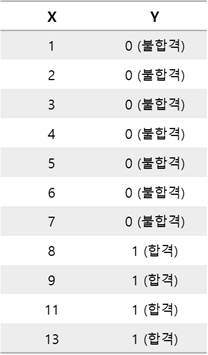

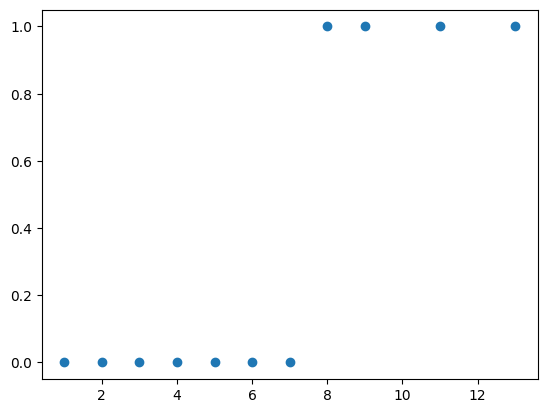

In [68]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1,2,3,4,5,6,7,8,9,11,13])
y = np.array([0,0,0,0,0,0,0,1,1,1,1])

plt.scatter(x,y)

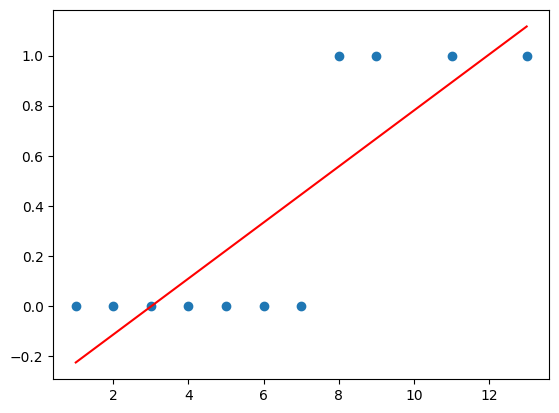

In [69]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x.reshape(-1,1), y)
plt.scatter(x,y)
plt.plot(x,reg.predict(x.reshape(-1,1)), c='red')

- 합격여부를 의미하는 Y값이 0과 1을 가지는 것이 아니라 -∞에서 +∞을 가지게 됨 (합격할 확률이 120%, -20%와 같이 나올 수 있음)
- 따라서 범주형 레이블에 회귀모델을 적용할 때는 로지스틱회귀분석을 적용

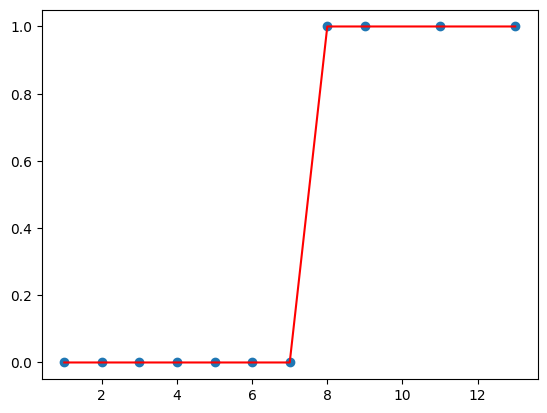

In [70]:
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression().fit(x.reshape(-1,1), y)
plt.scatter(x,y)
plt.plot(x,reg.predict(x.reshape(-1,1)), c='red')

# 분류 분석
- 하나 혹은 그 이상의 특성들을 이용하여 범주형 레이블을 예측하는 기법

## 분류 분석 성능 평가 척도
- 혼동행렬(Confusion Matrix): 예측값이 실제값과 일치하는지 분류하는 분류표
- 이진분류의 경우 예측한 범주와 실제 범주에 따라 4가지 지표로 볼 수 있음
    - True Positive(TP) : 실제 Positive, 예측 Positive
    - False Negative(FN) : 실제 Positive, 예측 Negative
    - False Positive(FP) : 실제 Negative, 예측 Positive
    - True Negative(TN) : 실제 Negative, 예측 Negative
    
    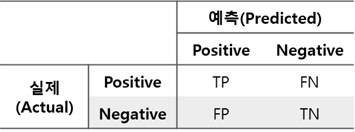

- 혼동행렬의 4가지 지표를 활용해 분류모델의 성능을 측정
    - 정확도(Accuracy)<br>
$Accuracy = \frac{(TP + TN)}{(TP+FN+FP+TN)}$
        - 전체 데이터 중 올바르게 분류한 비율
    - 재현율(Recall)<br>
$Recall = \frac{TP}{(TP+FN)}$
        - 실제 Positive 데이터 중 True Positive의 비율
    - 특이도(Specificity)<br>
$Specificity = \frac{TN}{(TN+FP)}$
        - 실제 Negative 데이터 중 True Negative의 비율
    - 정밀도(Precision)<br>
$Precision = \frac{TP}{(TP+FP)}$
        - Positive로 예측한 데이터 중 True Positive의 비율

# Logistic Regression
- 선형회귀 분석과 달리 예측하고자 하는 레이블이 범주형인 경우 사용되는 모델
- linear_model의 LogisticRegression에 구현되어 있음
```
LogisticRegression(class_weight=None,multi_class='auto')
```
    - class_weight : 클래스별 비율이 다를때 가중치 적용
        - None: 가중치  없음
        - balanced : 클래스별 비율 자동 조정 (전체데이터수 / 해당 클래스 개수)
        - {class_label: weight} : 클래스별 가중치에 대하여 딕셔너리 형태로 적용
    - multi_class : 클래스의 개수
        - ovr(one verse rest) : 이진분류
        - multinomial : 다중클래스 분류
- 로지스틱 회귀모델은 선형 회귀 모델 기반으로 확률 모델로 접근
- 예측하고자 하는 레이블의 값이 확률인 것 이외에는 단순 선형회귀 모델의 일반적인 형태와 동일
- 함수의 결과값이 0에서 1사이의 값을 반환하는 함수를 로지스틱 함수라고 함
    - 시그모이드(Sigmoid) 함수가 대표적임
- 로지스틱 회귀모델은 이진분류를 기본으로 함

### 가설
$H(x) = log(\frac{P(Y=1 | X=x)}{1 - P(Y=1 | X=x)}) = W^TX = \frac{1}{1+e^{-W^TX}}$

### 비용함수(손실함수)
- 확률이기 때문에 MSE가 아닌 Cross Entrophy 사용

$cost(W) = -\frac{1}{m} \sum ylog(H(x)) + (1-y)log(1-H(x))$

### 비용최소화
$W := W - lr\frac{\partial}{\partial W}cost(W) = W - lr\frac{1}{m}\sum(H(x) - y)x$

## 로지스틱 회귀의 특징
- 모델의 예측값은 범주 레이블으로 얻어질 수 없고, 범주별 확률값을 반환함
- 분류기준(Cut-off Value)을 정의하여 확률을 레이블로 변환

## 알고리즘 동작과정
1. 로지스틱 회귀 모델을 학습시켜 예측확률 P(Y=1|x=x) 계산
2. 분류기준(Cut-off, 기본값 0.5)를 결정
3. 예측확률이 분류기준보다 클 경우 1, 작을 경우 0으로 분류

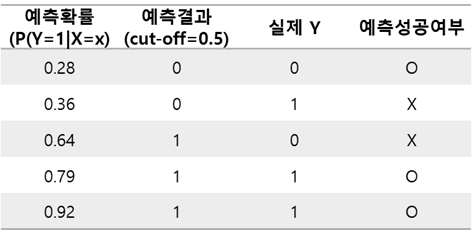

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

## [예제] iris 데이터 분류

In [72]:
# 데이터 추출
from sklearn.datasets import load_iris
iris = load_iris()

# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris.data,
                                                    iris.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [73]:
# 모델 학습 및 평가
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train,y_train)
print('Train Score :', log.score(X_train,y_train))
print('Test Score :', log.score(X_test,y_test))

Train Score : 0.9809523809523809
Test Score : 0.9777777777777777


In [75]:
# 데이터 예측값
log.predict(X_test)[:5]

array([2, 1, 0, 2, 0])

In [76]:
# 데이터 예측 확률
log.predict_proba(X_test)[:5]

array([[1.32111715e-04, 5.98143496e-02, 9.40053539e-01],
       [1.33629146e-02, 9.57002405e-01, 2.96346801e-02],
       [9.82953184e-01, 1.70467599e-02, 5.58997002e-08],
       [1.61981983e-06, 2.61468232e-02, 9.73851557e-01],
       [9.68238312e-01, 3.17614506e-02, 2.37151970e-07]])

In [77]:
# 클래스가 2개만 선택(이진분류)
X_data = iris.data[iris.target != 2]
y_data = iris.target[iris.target != 2]

X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    test_size=0.3,
                                                    random_state=0)

log = LogisticRegression()
log.fit(X_train,y_train)
print('Train Score :', log.score(X_train,y_train))
print('Test Score :', log.score(X_test,y_test))

Train Score : 1.0
Test Score : 1.0


In [78]:
# 데이터 예측값
log.predict(X_test)[:5]

array([0, 1, 0, 1, 1])

In [79]:
# 데이터 예측확률
log.predict_proba(X_test)[:5]

 # 컷오프보다 argumax로 생각하는 것도 좋은 방법이다.

array([[0.9592458 , 0.0407542 ],
       [0.00474177, 0.99525823],
       [0.98063576, 0.01936424],
       [0.0096775 , 0.9903225 ],
       [0.00938138, 0.99061862]])

In [80]:
# 회귀식의 결과 조회(데이터간의 거리 조회)
log.decision_function(X_test)[:5]
# -가 0이고 +(양수)가 1이다 라고 보면 된다.
# 절대값이 크면 클수록 우리의 결정에 대한 확신도가 커진다.

array([-3.15858833,  5.34659163, -3.92477318,  4.62822723,  4.65960313])

# [실습] 유방암 진단 결과에 대한 분류
- sklearn의 load_breast_cancer를 이용하여 유방암 데이터 추출
- 이에 대한 분류분석 수행

### 나

In [81]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [ ]:
print(cancer.DESCR)
# Class Distribution: 212 - Malignant, 357 - Benign 클래스에 차이가 있다
# 이때 가중치를 줘도 되고, 그대로 해도 된다.

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [82]:
# 데이터 분할
# 이미 0하고 1로 이진 분류
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(cancer.data,
                                                    cancer.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [84]:
# 표준화
scaler = StandardScaler()  # 객체 생성
X_train_scaled = scaler.fit_transform(X_train)  # 훈련 데이터: fit + transform
X_test_scaled = scaler.transform(X_test)  # 테스트 데이터: transform만 적용

In [85]:
# 모델 학습 및 평가
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train_scaled,y_train)
print('Train Score :', log.score(X_train_scaled,y_train))
print('Test Score :', log.score(X_test_scaled,y_test))

Train Score : 0.9899497487437185
Test Score : 0.9766081871345029


In [87]:
# 데이터 예측값
log.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [90]:
# 데이터 예측 확률
log.predict_proba(X_test)[:5]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [94]:
# 회귀식의 결과 조회(데이터간의 거리 조회)
log.decision_function(X_test)[:5]

array([-1117.94138157,  -903.2920532 ,  -964.88915484, -1100.89664526,
        -800.94424984])

### 강사님

In [ ]:
# 데이터 추출
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
# 데이터 분할
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(cancer.data,
                                                    cancer.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [ ]:
# 모델 학습 및 평가 (100번 반복 : default)
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train, y_train)

print('Train score', log.score(X_train, y_train))
print('Test score', log.score(X_test, y_test))

Train score 0.957286432160804
Test score 0.9590643274853801


In [ ]:
# 클래스 가중치를 적용한 모델 학습
log_b = LogisticRegression(class_weight='balanced')
log_b.fit(X_train, y_train)

print('Train score', log_b.score(X_train, y_train))
print('Test score', log_b.score(X_test, y_test))

Train score 0.9422110552763819
Test score 0.9473684210526315


In [ ]:
# 10000번 반복 학습
log10000 = LogisticRegression(max_iter=10000)
log10000.fit(X_train, y_train)

print('Train score', log10000.score(X_train, y_train))
print('Test score', log10000.score(X_test, y_test))

Train score 0.9597989949748744
Test score 0.9590643274853801
